## 1. Importação

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais de alto padrão
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Carregando a base tratada do Notebook 1
caminho_dados = '../data/processed/data_model/data_model.csv'
df_aed = pd.read_csv(caminho_dados, sep=';')

print(f"Base carregada para AED Visual! Formato: {df_aed.shape}")

Base carregada para AED Visual! Formato: (216734, 84)


## 2. Periculosidade Média por Rodovia

C:\Users\gabriel.athayde\AppData\Local\Temp\ipykernel_12644\543286991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


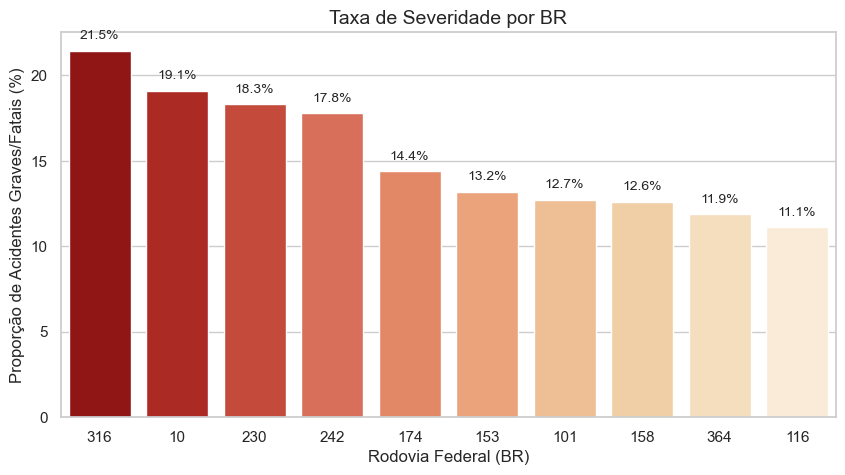

In [10]:
# Calculando a Taxa de Acidentes Graves/Fatais por BR (em %)
periculosidade_br = df_aed.groupby('br')['acidente_grave_ou_fatal'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(
    x=periculosidade_br.index, 
    y=periculosidade_br.values, 
    order=periculosidade_br.index, 
    palette='OrRd_r' # Paleta quente para indicar severidade
)

plt.title('Taxa de Severidade por BR')
plt.ylabel('Proporção de Acidentes Graves/Fatais (%)')
plt.xlabel('Rodovia Federal (BR)')

# Adicionando os rótulos
for i, valor in enumerate(periculosidade_br.values):
    plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', va='bottom', fontsize=10)

plt.show()

## 3. Qualidade da Via (ICM) vs. Severidade do Acidente

C:\Users\gabriel.athayde\AppData\Local\Temp\ipykernel_12644\3699118824.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


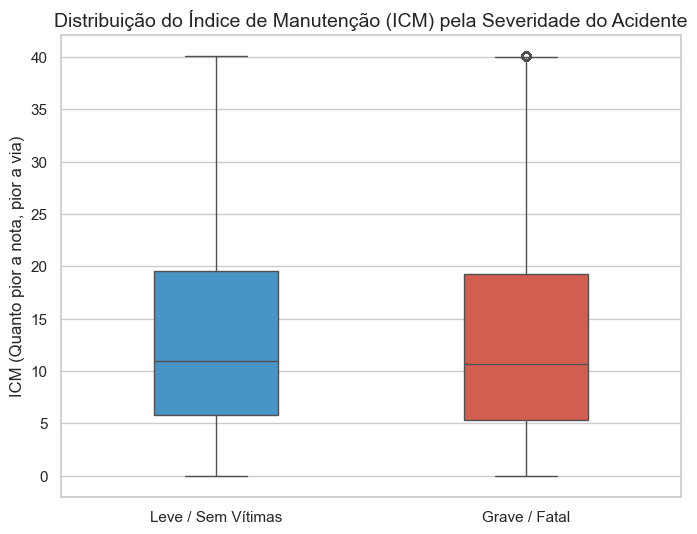

In [11]:
plt.figure(figsize=(8, 6))

# Criando o boxplot comparativo
sns.boxplot(
    data=df_aed, 
    x='acidente_grave_ou_fatal', 
    y='icm', 
    palette=['#3498db', '#e74c3c'],
    width=0.4
)

plt.title('Distribuição do Índice de Manutenção (ICM) pela Severidade do Acidente')
plt.xticks([0, 1], ['Leve / Sem Vítimas', 'Grave / Fatal'])
plt.ylabel('ICM (Quanto pior a nota, pior a via)')
plt.xlabel('')

plt.show()

## 4. Correlação Direta: Degradação vs. Periculosidade no Trecho

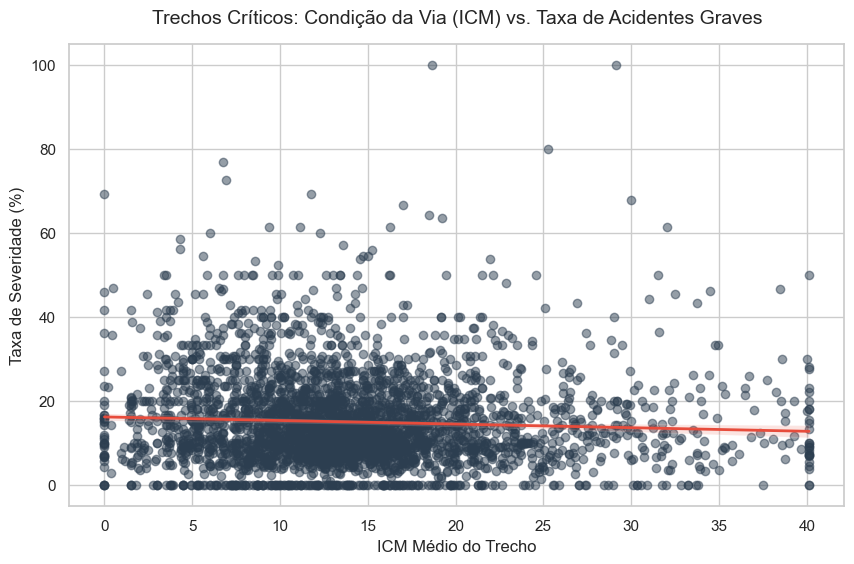

In [12]:
# 1. Agrupando por trecho específico da rodovia (BR + KM)
trechos = df_aed.groupby(['br', 'km_join']).agg(
    total_acidentes=('acidente_grave_ou_fatal', 'count'),
    taxa_severidade=('acidente_grave_ou_fatal', 'mean'),
    icm_medio=('icm', 'mean')
).reset_index()

# 2. Filtrando trechos com pelo menos 10 acidentes para evitar ruído estatístico
trechos_criticos = trechos[trechos['total_acidentes'] >= 10].copy()
trechos_criticos['taxa_severidade'] = trechos_criticos['taxa_severidade'] * 100

# 3. Plotagem do gráfico de dispersão com linha de tendência
plt.figure(figsize=(10, 6))
sns.regplot(
    data=trechos_criticos, 
    x='icm_medio', 
    y='taxa_severidade',
    scatter_kws={'alpha':0.5, 'color': '#2c3e50'}, 
    line_kws={'color':'#e74c3c', 'linewidth': 2}
)

plt.title('Trechos Críticos: Condição da Via (ICM) vs. Taxa de Acidentes Graves', pad=15)
plt.xlabel('ICM Médio do Trecho')
plt.ylabel('Taxa de Severidade (%)')

plt.show()